# Stonk Teller — modelo LSTM pra prever o preço da AAPL

## A jornada até esse modelo funcionar

### Tentativa 1: dataset completo (1984–2026)

- Baixei o histórico inteiro da AAPL e mandei pro modelo.
- Loss treino: 0.00094 (ótima). Loss val: 0.25 (péssima). Diferença de ~270x.
- **Erro:** AAPL de 1984 não tem nada a ver com a de 2024 (preço pré-IPO ajustado ~$0.10). Com split 80/20 temporal, o modelo treinou em 1984–2017 e foi avaliado em 2017–2026 — distribuições completamente diferentes. Overfitting clássico.
- **Correção:** filtrei o dataset pra começar em 2018-01-01.

### Tentativa 2: filtro 2018+ + scaler na série inteira

- Loss val caiu pra ~0.11. Achei que tava resolvido.
- Métricas finais: MAE $86, MAPE 35%. Modelo errando um terço do preço.
- **Erro:** data leakage no `MinMaxScaler`. Usei `fit_transform` na série inteira, então o scaler aprendeu o `min`/`max` olhando dados de validação. A loss em escala normalizada parecia ok, mas quando eu desnormalizava, o erro real explodia.
- Pensei em embaralhar o split pra "misturar" preços altos e baixos. Pesquisando, descobri que isso é um erro grosseiro em série temporal: as janelas se sobrepõem e o modelo decora o passado em vez de aprender a prever o futuro (overfitting disfarçado de bom desempenho).
- **Correção:** scaler ajustado SÓ com dados de treino, depois aplicado em tudo.

### Tentativa 3: scaler corrigido (sem leakage)

- Loss val começou alta (~0.8) e caiu honestamente pra ~0.17. Sem o leakage escondendo o problema.
- Mas as métricas continuaram horríveis: MAE $91, MAPE 37%.
- Plotei real vs previsto e ficou óbvio: a linha real subia até $290, a linha prevista ficava travada por volta de $160, sem conseguir acompanhar.
- **Erro:** problema de extrapolação. AAPL atingiu picos novos no período de validação (>$220) que o modelo nunca viu durante o treino. Como LSTM trabalha melhor com dados estacionários (sem tendência), prever preço bruto de uma ação que sobe ao longo do tempo é estruturalmente difícil.
- **Correção:** mudar o alvo. Em vez de prever o preço de amanhã, prever a variação diária (delta). Deltas oscilam em torno de zero, são mais ou menos estacionários, e funcionam bem em qualquer faixa de preço. Pra reconstruir o preço final, somo o delta previsto ao preço de hoje.

### Tentativa 4: prever delta em vez de preço

- Trocada a normalização: agora opero em `np.diff(precos)` com `feature_range=(-1, 1)` (deltas podem ser negativos).
- Reconstrução na avaliação: `preço_previsto = preço_de_ontem + delta_previsto`.
- **Resultado:** MAE $2.75, RMSE $4.03, MAPE 1.18%. Gráfico real vs previsto agora acompanha de perto.

In [1]:
import pandas as pd

df = pd.read_csv('../data/aapl.csv', index_col='Date', parse_dates=True)
df = df.sort_index()
df = df.loc['2018-01-01':]   # corta tudo antes de 2018
print(df.shape)
df.head()

(2099, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,39.8130,40.3127,39.6024,40.3038,109069688
2018-01-03,40.3675,40.8366,40.2312,40.2969,125940453
2018-01-04,40.3694,40.5891,40.2605,40.4874,95519129
2018-01-05,40.5813,41.0347,40.4934,40.9435,100851184
2018-01-08,40.7933,41.0887,40.6974,40.8032,87746713


Para este modelo, vamos usar só Close.

(2099, 5)
count    2099.000000
mean      140.736255
std        70.191554
min        33.767900
25%        67.448800
50%       145.349000
75%       189.528000
max       293.320000
Name: Close, dtype: float64


<Axes: title={'center': 'AAPL - Preço de Fechamento'}, xlabel='Date'>

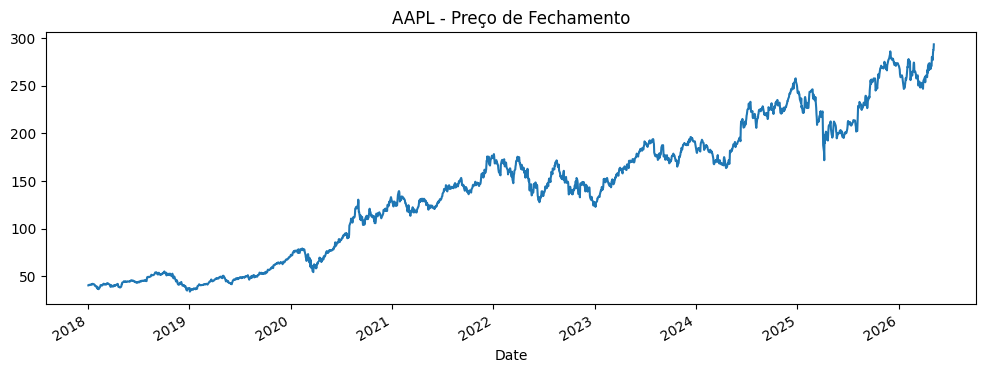

In [2]:
print(df.shape)
print(df['Close'].describe())
df['Close'].plot(figsize=(12,4), title='AAPL - Preço de Fechamento')

## Pré-processamento

O preço em dólares varia muito aqui, de 50 a 300. Vou normalizar para 0-1 para facilitar o aprendizado da LSTM, com MinMaxScaler na SciKit-Learn.

**Problema**:
- Primeiro eu tinha normalizado a série inteira de uma vez com `scaler.fit_transform(precos)`.
- Mesmo com a loss de validação aceitável (~0.11), as métricas finais ficaram horríveis: MAE $86, MAPE 35%. Modelo errando um terço do preço.

**Investigação**:
- Data leakage no `MinMaxScaler`.
- O que tava errado: usei `fit_transform` na série inteira, ou seja, o scaler aprendeu o `min` e `max` olhando dados de validação também. Como a AAPL bateu picos novos no período de validação, o modelo nunca viu preços nessa faixa durante o treino e cuspia valores muito abaixo do real.
- Pensei em embaralhar o split treino/validação pra "misturar" os preços altos e baixos, mas pesquisando aprendi que isso é um erro em série temporal: as janelas se sobrepõem, e o modelo acabaria com overfitting.

**Solução**:
- Manter o split temporal (treino = passado, validação = futuro), mas ajustar o scaler **só** com dados de treino e depois aplicar a transformação em tudo.
- Código novo: `scaler.fit(precos_treino)` separado, e depois `scaler.transform(precos)` no array inteiro antes de criar as janelas.

In [3]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# preços brutos
precos = df['Close'].values.reshape(-1, 1)

# calcula a variação diária (delta)
deltas = np.diff(precos, axis=0)   # shape (n-1, 1)

# split temporal nos DELTAS
tamanho_treino = int(len(deltas) * 0.8)
deltas_treino = deltas[:tamanho_treino]

# scaler aprende SÓ com deltas de treino
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(deltas_treino)

# aplica em todos os deltas
deltas_norm = scaler.transform(deltas)

print('deltas:', deltas.shape)
print('range deltas treino:', deltas_treino.min(), deltas_treino.max())

deltas: (2098, 1)
range deltas treino: -10.50800000000001 13.924000000000007


Sequência de n dias para a LSTM prever o dia seguinte. Vamos de 60 dias como prazo padrão:

In [4]:
def criar_sequencias(serie, janela=60):
    X, y = [], []
    for i in range(janela, len(serie)):
        X.append(serie[i-janela:i, 0])
        y.append(serie[i, 0])
    return np.array(X), np.array(y)

X, y = criar_sequencias(deltas_norm, janela=60)
print(X.shape, y.shape)

(2038, 60) (2038,)


In [5]:
tamanho_treino_X = int(len(X) * 0.8)
X_treino, X_val = X[:tamanho_treino_X], X[tamanho_treino_X:]
y_treino, y_val = y[:tamanho_treino_X], y[tamanho_treino_X:]
print(X_treino.shape, X_val.shape)

(1630, 60) (408, 60)


Converter para tensores PyTorch:

In [6]:
import torch

X_treino = torch.tensor(X_treino, dtype=torch.float32).unsqueeze(-1)  # (n, 60, 1)
y_treino = torch.tensor(y_treino, dtype=torch.float32).unsqueeze(-1)  # (n, 1)
X_val    = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1)
y_val    = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

## Construção do modelo LSTM

Classe: 1 camada LSTM + 1 camada linear de saída

In [7]:
import torch.nn as nn

class ModeloLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)        # out: (batch, seq, hidden)
        out = out[:, -1, :]          # pega só o último passo
        out = self.linear(out)       # (batch, 1)
        return out

model = ModeloLSTM()
print(model)


ModeloLSTM(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)


## Treinar o modelo

Loss function: MSELoss; Otimizador: Adam

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Loop de treinamento

In [9]:
epocas = 30

for epoca in range(epocas):
    model.train()
    optimizer.zero_grad()
    pred = model(X_treino)
    loss = criterion(pred, y_treino)
    loss.backward()
    optimizer.step()

    # validação
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val)
        loss_val = criterion(pred_val, y_val)

    print(f'Época {epoca+1}/{epocas} | Loss treino: {loss.item():.5f} | Loss val: {loss_val.item():.5f}')

Época 1/30 | Loss treino: 0.03721 | Loss val: 0.10961
Época 2/30 | Loss treino: 0.03631 | Loss val: 0.10899
Época 3/30 | Loss treino: 0.03578 | Loss val: 0.10872
Época 4/30 | Loss treino: 0.03558 | Loss val: 0.10870
Época 5/30 | Loss treino: 0.03563 | Loss val: 0.10881
Época 6/30 | Loss treino: 0.03579 | Loss val: 0.10892
Época 7/30 | Loss treino: 0.03592 | Loss val: 0.10895
Época 8/30 | Loss treino: 0.03596 | Loss val: 0.10892
Época 9/30 | Loss treino: 0.03591 | Loss val: 0.10884
Época 10/30 | Loss treino: 0.03581 | Loss val: 0.10877
Época 11/30 | Loss treino: 0.03570 | Loss val: 0.10872
Época 12/30 | Loss treino: 0.03562 | Loss val: 0.10871
Época 13/30 | Loss treino: 0.03558 | Loss val: 0.10874
Época 14/30 | Loss treino: 0.03557 | Loss val: 0.10879
Época 15/30 | Loss treino: 0.03559 | Loss val: 0.10885
Época 16/30 | Loss treino: 0.03563 | Loss val: 0.10890
Época 17/30 | Loss treino: 0.03566 | Loss val: 0.10893
Época 18/30 | Loss treino: 0.03568 | Loss val: 0.10893
Época 19/30 | Loss 

## Avaliar o modelo

Primeiro precisamos desnormalizar: os valores estão 0-1 e precisamos voltar para USD.

In [10]:
model.eval()
with torch.no_grad():
    pred_delta_norm = model(X_val).numpy()

# desnormaliza o delta previsto
pred_delta_real = scaler.inverse_transform(pred_delta_norm)

# desnormaliza o delta REAL (alvo)
y_delta_real = scaler.inverse_transform(y_val.numpy())

# pega os preços de "ontem" correspondentes a cada exemplo de validação
# o índice de cada y_val no array original de preços
# precos[60] é o primeiro y de criar_sequencias; o val começa em tamanho_treino_X
# ontem = precos[60 + tamanho_treino_X - 1] em diante? deixa eu fazer com clareza:

# como deltas[i] = precos[i+1] - precos[i],
# e a janela usa deltas[i-60:i] pra prever deltas[i],
# então y_val[k] corresponde a deltas[60 + tamanho_treino_X + k]
# que é a variação entre precos[60 + tamanho_treino_X + k]  e precos[60 + tamanho_treino_X + k + 1]
# então o "preço de ontem" é precos[60 + tamanho_treino_X + k]

inicio_val = 60 + tamanho_treino_X
precos_ontem = precos[inicio_val : inicio_val + len(y_val)]   # shape (n_val, 1)

# soma delta ao preço de ontem
pred_val_real = precos_ontem + pred_delta_real
y_val_real    = precos_ontem + y_delta_real

Calcular MAE, RMSE, MAPE:

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_val_real, pred_val_real)
rmse = np.sqrt(mean_squared_error(y_val_real, pred_val_real))
mape = np.mean(np.abs((y_val_real - pred_val_real) / y_val_real)) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.2f}%')

MAE:  2.7494
RMSE: 4.0294
MAPE: 1.18%


## Plotar previsão vs. real

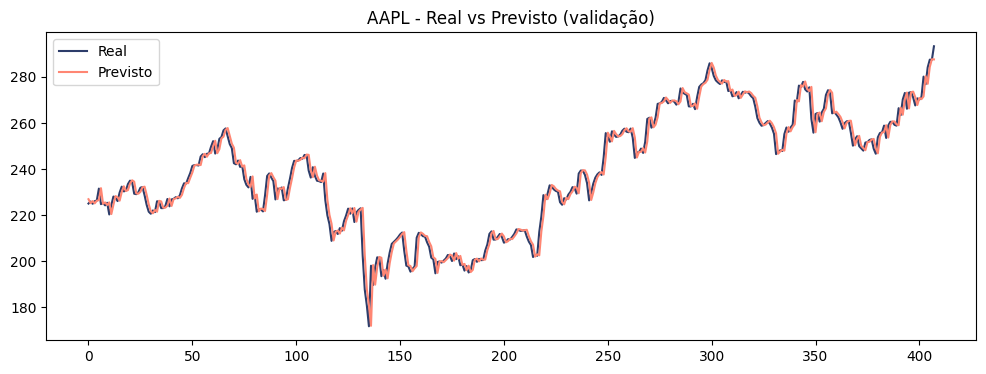

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_val_real, label='Real', color='#2D3D6A')
plt.plot(pred_val_real, label='Previsto', color='#FF8673')
plt.title('AAPL - Real vs Previsto (validação)')
plt.legend()
plt.show()

## Salvar o modelo

Salvar os pesos do modelo:

In [14]:
torch.save(model.state_dict(), '../saved_model/model.pth')

Salvar o scaler:

In [15]:
import joblib
joblib.dump(scaler, '../saved_model/scaler.pkl')

['../saved_model/scaler.pkl']

Salvar metadados:

In [17]:
import json
metadados = {
    'symbol': 'AAPL',
    'janela': 60,
    'hidden_size': 50,
    'num_layers': 1,
    'modo': 'delta'
}
with open('../saved_model/metadados.json', 'w') as f:
    json.dump(metadados, f)